<a href="https://colab.research.google.com/github/devanshrai1300-wq/movie_recommendation-/blob/main/movie_recommendations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

In [3]:
movies.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800


In [7]:
credits.head(1)


,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [8]:
movies = movies.merge(credits,on='title')

In [9]:
movies = movies[['movie_id','title','overview','genres','keywords','cast','crew']]

In [10]:
movies.head()


,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [11]:
movies.isnull().sum()

,0
movie_id,0
title,0
overview,3
genres,0
keywords,0
cast,0
crew,0


In [12]:
movies.dropna(inplace=True)

In [13]:
movies.duplicated().sum()

np.int64(0)

In [14]:
import ast


In [15]:
def convert(obj):
    L = []
    for i in ast.literal_eval(obj):
        L.append(i['name'])
    return L

In [16]:
movies['genres'] = movies['genres'].apply(convert)

In [17]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [18]:
def convert_robust(obj):
    # If the object is already a list, it means it has been processed before
    # or is already in a list format, so we can return it directly.
    if isinstance(obj, list):
        return obj

    L = []
    try:
        # Ensure obj is a non-empty string before attempting literal_eval
        if not isinstance(obj, str) or obj.strip() == '':
            return []

        evaluated_list = ast.literal_eval(obj)
        for i in evaluated_list:
            if isinstance(i, dict) and 'name' in i:
                L.append(i['name'])
    except (ValueError, SyntaxError, TypeError):
        # Catch errors if ast.literal_eval cannot parse the string
        # or if other unexpected types are encountered during iteration.
        return []
    return L

movies['keywords'] = movies['keywords'].apply(convert_robust)

In [19]:
def convert3(obj):
    if isinstance(obj, list):
        return obj[:3]
    L = []
    counter = 0
    for i in ast.literal_eval(obj):
        if counter != 3:
            L.append(i['name'])
            counter += 1
        else:
            break
    return L

In [20]:
movies['cast'] = movies['cast'].apply(convert3)
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux]","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman]","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton]","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [21]:
movies['cast'] = movies['cast'].apply(lambda x:x[0:3])
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux]","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman]","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton]","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [22]:
def fetch_director(obj):
    L = []
    for i in ast.literal_eval(obj):
        if i['job'] == 'Director':
            L.append(i['name'])
            break
    return L

In [23]:
import ast

def fetch_director_robust(obj):
    if isinstance(obj, list):
        return obj
    L = []
    for i in ast.literal_eval(obj):
        if i['job'] == 'Director':
            L.append(i['name'])
            break
    return L

movies['crew'] = movies['crew'].apply(fetch_director_robust)

In [24]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron]
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski]
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes]
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan]
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton]


movies['overview'] = movies['overview'].apply(lambda x:x.split())

In [ ]:
movies['overview'] = movies['overview'].apply(lambda x:x.split())

In [28]:
movies['genres'] = movies['genres'].apply(lambda x:[i.replace(" ","") for i in x])
movies['keywords'] = movies['keywords'].apply(lambda x:[i.replace(" ","") for i in x])
movies['cast'] = movies['cast'].apply(lambda x:[i.replace(" ","") for i in x])
movies['crew'] = movies['crew'].apply(lambda x:[i.replace(" ","") for i in x])


In [29]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ...","[SamWorthington, ZoeSaldana, SigourneyWeaver]",[JamesCameron]
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[Adventure, Fantasy, Action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[JohnnyDepp, OrlandoBloom, KeiraKnightley]",[GoreVerbinski]
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[Action, Adventure, Crime]","[spy, basedonnovel, secretagent, sequel, mi6, ...","[DanielCraig, ChristophWaltz, LéaSeydoux]",[SamMendes]
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[Action, Crime, Drama, Thriller]","[dccomics, crimefighter, terrorist, secretiden...","[ChristianBale, MichaelCaine, GaryOldman]",[ChristopherNolan]
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[Action, Adventure, ScienceFiction]","[basedonnovel, mars, medallion, spacetravel, p...","[TaylorKitsch, LynnCollins, SamanthaMorton]",[AndrewStanton]


In [30]:
movies['tag'] = movies['overview'] + movies['genres'] + movies['keywords'] + movies['cast'] + movies['crew']

In [31]:
new_df = movies[['movie_id','title','tag']]

In [32]:
new_df['tag'] = new_df['tag'].apply(lambda x:" ".join(x))

/tmp/ipykernel_3845/2072057965.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tag'] = new_df['tag'].apply(lambda x:" ".join(x))


In [33]:
new_df['tag'] = new_df['tag'].apply(lambda x:x.lower())

/tmp/ipykernel_3845/1436014886.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tag'] = new_df['tag'].apply(lambda x:x.lower())


In [34]:
new_df.head()

,movie_id,title,tag
0,19995,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,206647,Spectre,a cryptic message from bond’s past sends him o...
3,49026,The Dark Knight Rises,following the death of district attorney harve...
4,49529,John Carter,"john carter is a war-weary, former military ca..."


In [44]:
import nltk

In [45]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [46]:
def stem(text):
    y = []
    for i in text.split():
        y.append(ps.stem(i))
    return " ".join(y)

In [47]:
new_df['tag'] = new_df['tag'].apply(stem)

/tmp/ipykernel_3845/4074900442.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tag'] = new_df['tag'].apply(stem)


In [48]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=5000,stop_words='english')

In [56]:
vectors = cv.fit_transform(new_df['tag']).toarray()

In [50]:
def stem(text):
    y = []
    for i in text.split():
        y.append(ps.stem(i))
    return " ".join(y)

In [52]:
from sklearn.metrics.pairwise import cosine_similarity

In [57]:
similarity = cosine_similarity(vectors)
similarity

array([[1.        , 0.08346223, 0.0860309 , ..., 0.04499213, 0.        ,
        0.        ],
       [0.08346223, 1.        , 0.06063391, ..., 0.02378257, 0.        ,
        0.02615329],
       [0.0860309 , 0.06063391, 1.        , ..., 0.02451452, 0.        ,
        0.        ],
       ...,
       [0.04499213, 0.02378257, 0.02451452, ..., 1.        , 0.03962144,
        0.04229549],
       [0.        , 0.        , 0.        , ..., 0.03962144, 1.        ,
        0.08714204],
       [0.        , 0.02615329, 0.        , ..., 0.04229549, 0.08714204,
        1.        ]])

In [60]:
def recommend(movie):
    movie_index = new_df[new_df['title'] == movie].index[0]
    distances = similarity[movie_index]
    movies_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]

    print(f'Recommendations for {movie}:')
    for i in movies_list:
        print(new_df.iloc[i[0]].title)

In [61]:
recommend('Avatar')

Recommendations for Avatar:
Aliens vs Predator: Requiem
Aliens
Falcon Rising
Independence Day
Titan A.E.


In [58]:
def recommend(movie):
    # Find the index of the movie
    movie_index = new_df[new_df['title'] == movie].index[0]
    # Get similarity scores for that movie and sort them
    distances = similarity[movie_index]
    movies_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]

    print(f"Recommendations for '{movie}':")
    for i in movies_list:
        print(new_df.iloc[i[0]].title)

In [59]:
recommend('Avatar')

Recommendations for 'Avatar':
Aliens vs Predator: Requiem
Aliens
Falcon Rising
Independence Day
Titan A.E.


In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Using Tfidf instead of CountVectorizer to better weight unique terms
tfidf = TfidfVectorizer(max_features=10000, stop_words='english')
vectors_tfidf = tfidf.fit_transform(new_df['tag']).toarray()

# Calculate new similarity matrix
similarity_tfidf = cosine_similarity(vectors_tfidf)

def recommend_improved(movie):
    if movie not in new_df['title'].values:
        print('Movie not found.')
        return
    movie_index = new_df[new_df['title'] == movie].index[0]
    distances = similarity_tfidf[movie_index]
    movies_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]

    print(f"Improved recommendations for '{movie}':")
    for i in movies_list:
        print(new_df.iloc[i[0]].title)

In [64]:
recommend_improved('Avatar')

Improved recommendations for 'Avatar':
Aliens
Falcon Rising
Battle: Los Angeles
Apollo 18
Aliens vs Predator: Requiem


In [71]:
from sklearn.preprocessing import MinMaxScaler

# Reloading to get the popularity column
original_movies = pd.read_csv('tmdb_5000_movies.csv')

# Merging popularity into new_df using movie_id
new_df = new_df.copy()
new_df = new_df.merge(original_movies[['id', 'popularity']], left_on='movie_id', right_on='id').drop('id', axis=1)

# Normalize popularity so it's on a comparable scale (0 to 1)
scaler = MinMaxScaler()
new_df['normalized_popularity'] = scaler.fit_transform(new_df[['popularity']])

def recommend_with_popularity(movie, weight=0.8):
    if movie not in new_df['title'].values:
        print('Movie not found.')
        return

    movie_index = new_df[new_df['title'] == movie].index[0]

    # Get similarity scores
    sim_scores = similarity_tfidf[movie_index]

    # Combine similarity with normalized popularity
    pop_scores = new_df['normalized_popularity'].values
    combined_scores = (sim_scores * weight) + (pop_scores * (1 - weight))

    # Sort based on combined score
    movies_list = sorted(list(enumerate(combined_scores)), reverse=True, key=lambda x: x[1])[1:6]

    print(f"Recommendations for '{movie}' (Weighted with Popularity):")
    for i in movies_list:
        print(f"{new_df.iloc[i[0]].title} (Popularity Score: {new_df.iloc[i[0]].popularity:.2f})")

In [72]:
# Re-calling the hybrid recommendation function
recommend_with_popularity('Avatar')

Recommendations for 'Avatar' (Weighted with Popularity):
Minions (Popularity Score: 875.58)
Interstellar (Popularity Score: 724.25)
Aliens (Popularity Score: 67.66)
Guardians of the Galaxy (Popularity Score: 481.10)
Mad Max: Fury Road (Popularity Score: 434.28)


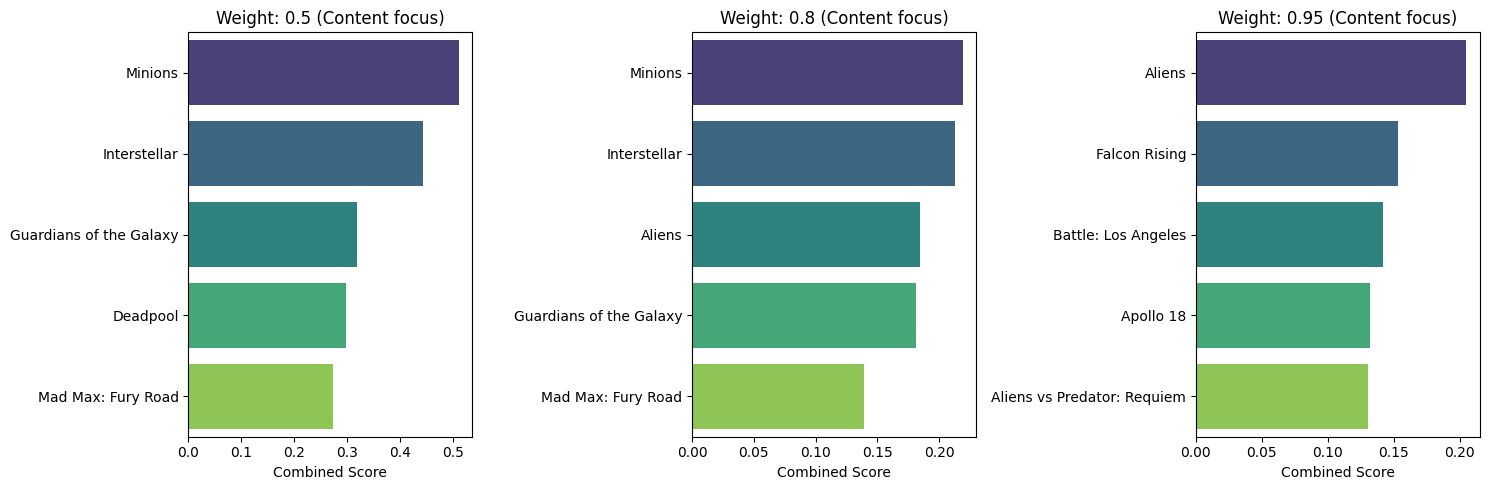

In [74]:
def get_recommendations_data(movie, weight):
    movie_index = new_df[new_df['title'] == movie].index[0]
    sim_scores = similarity_tfidf[movie_index]
    pop_scores = new_df['normalized_popularity'].values
    combined_scores = (sim_scores * weight) + (pop_scores * (1 - weight))
    movies_list = sorted(list(enumerate(combined_scores)), reverse=True, key=lambda x: x[1])[1:6]
    return [(new_df.iloc[i[0]].title, combined_scores[i[0]]) for i in movies_list]

weights = [0.5, 0.8, 0.95]
plt.figure(figsize=(15, 5))

for i, w in enumerate(weights, 1):
    data = get_recommendations_data('Avatar', w)
    titles, scores = zip(*data)

    plt.subplot(1, 3, i)
    # Fixed the FutureWarning by assigning y to hue and setting legend=False
    sns.barplot(x=list(scores), y=list(titles), hue=list(titles), palette='viridis', legend=False)
    plt.title(f'Weight: {w} (Content focus)')
    plt.xlabel('Combined Score')

plt.tight_layout()
plt.show()

In [75]:
!pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.4/596.4 kB 14.3 MB/s eta 0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.5.1
    Uninstalling sentence-transformers-5.5.1:
      Successfully uninstalled sentence-transformers-5.5.1


In [76]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Initialize the BERT model (all-MiniLM-L6-v2 is fast and efficient)
bert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings for all movie tags
# This might take a minute depending on the dataset size
print("Generating BERT embeddings...")
vectors_bert = bert_model.encode(new_df['tag'].tolist(), show_progress_bar=True)

# Calculate cosine similarity matrix for BERT vectors
similarity_bert = cosine_similarity(vectors_bert)

print("BERT Similarity Matrix ready.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating BERT embeddings...


Batches:   0%|          | 0/151 [00:00<?, ?it/s]

BERT Similarity Matrix ready.


In [77]:
def recommend_bert(movie, weight=0.8):
    if movie not in new_df['title'].values:
        print('Movie not found.')
        return

    movie_index = new_df[new_df['title'] == movie].index[0]

    # Using BERT-based similarity scores
    sim_scores = similarity_bert[movie_index]

    # Combine with popularity
    pop_scores = new_df['normalized_popularity'].values
    combined_scores = (sim_scores * weight) + (pop_scores * (1 - weight))

    movies_list = sorted(list(enumerate(combined_scores)), reverse=True, key=lambda x: x[1])[1:6]

    print(f"BERT-Powered Recommendations for '{movie}':")
    for i in movies_list:
        print(f"{new_df.iloc[i[0]].title} (Score: {combined_scores[i[0]]:.2f})")

recommend_bert('Avatar')

BERT-Powered Recommendations for 'Avatar':
Interstellar (Score: 0.60)
Guardians of the Galaxy (Score: 0.47)
Minions (Score: 0.46)
Battle: Los Angeles (Score: 0.46)
Mad Max: Fury Road (Score: 0.46)


In [78]:
def recommend_bert(movie, weight=0.8):
    if movie not in new_df['title'].values:
        print(f"Movie '{movie}' not found in the database.")
        return

    # Get the index of the movie
    movie_index = new_df[new_df['title'] == movie].index[0]

    # Use BERT-based similarity scores
    sim_scores = similarity_bert[movie_index]

    # Combine similarity with normalized popularity scores
    pop_scores = new_df['normalized_popularity'].values
    combined_scores = (sim_scores * weight) + (pop_scores * (1 - weight))

    # Sort movies based on combined scores and exclude the movie itself
    movies_list = sorted(list(enumerate(combined_scores)), reverse=True, key=lambda x: x[1])[1:6]

    print(f"BERT-Powered Semantic Recommendations for '{movie}':")
    print("-" * 50)
    for i in movies_list:
        movie_title = new_df.iloc[i[0]].title
        final_score = combined_scores[i[0]]
        print(f"{movie_title:<35} | Combined Score: {final_score:.4f}")

In [79]:
# Test the new semantic recommendation function
recommend_bert('Avatar', weight=0.8)

BERT-Powered Semantic Recommendations for 'Avatar':
--------------------------------------------------
Interstellar                        | Combined Score: 0.5980
Guardians of the Galaxy             | Combined Score: 0.4744
Minions                             | Combined Score: 0.4597
Battle: Los Angeles                 | Combined Score: 0.4586
Mad Max: Fury Road                  | Combined Score: 0.4575


In [81]:
recommend_bert('The Dark Knight Rises', weight=0.8)

BERT-Powered Semantic Recommendations for 'The Dark Knight Rises':
--------------------------------------------------
Batman Forever                      | Combined Score: 0.6067
The Dark Knight                     | Combined Score: 0.5898
Batman Begins                       | Combined Score: 0.5840
Batman Returns                      | Combined Score: 0.5808
Batman                              | Combined Score: 0.5602
